# Machine Learning

<div dir='rtl'>
    <p><b>Artificial Intelligence (Ai)</b>: هو محاوله جعل الاله تحاكى ذكاء البشر عن طريق تعليم الاله بنفسها</p>
    <p><b>Machine Learning (ML)</b>: تعليم الاله هو فرع من فروع الـ <code>Ai</code> ويتم ذالك عن طريق بيانات واحصائيات لتعلم النمط الصحيح</p>
    <p><b>Deep Learning (DL)</b>: التعليم العمبق هو فرع من فروع <code>ML</code> ويستخدم <code>Neural Networks</code> (الشبكات العصبيه) لتحاكى مخ الانسان، مثل التعرف على الوجوه، فهم النصوص مثل <code>chatGPT</code>، تعليم القياده الاليه مثل <code>tesla</code></p>
    <div style="text-align: center;">
        <img src='mls.jpg' width=500 />
    </div>
    <hr/>
    <h3>كيف تتعلم الاله؟</h3>
    <ol>
        <li><b>Supervised Learning</b>: التعليم الموجه هو اعطاء بيانات منظمه عن طريق تقسيم البيانات الى x (Futures) (الاسئله) و y (target) (الاجابه)
        </li>
        <li><b>Unsupervised Learning</b>: التعليم الغير موجه هو اعطاء بيانات بها Futures فقط والاله تبحث عن الانماط وتصنف البانات على حسب التشابه</li>
    </ol>
    <div style="text-align: center;">
        <img src='unsupervised.gif' width=600 />
        <img src='supervised.gif' width=600 />
    </div>
    <p>اليوم سوف نستخدم مكتبة <code>scikit-learn</code>، هذه المكتبه سهلة الاستخدام وبها <code>models</code> جاهزه</p>
    <p><b>Model</b>: هو نسخه من خوازميات مكتوبه لتعليم الاله</p>
    <p>فى هذا الكورس سوف نتعلم <code>ML</code> لكى نتنبئ بالـ <code>Global_Sales</code> عن طريق <code>NA_Sales</code></p>
</div>


`pip install scikit-learn`

## Setup

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

## Clean up Data

In [2]:
df = pd.read_csv(
    "vgsales.csv",
    dtype={
        "NA_Sales": np.float32,
        "EU_Sales": np.float32,
        "JP_Sales": np.float32,
        "Other_Sales": np.float32,
        "Global_Sales": np.float32,
    }
)
df.drop(columns=["Rank", "Name", "Platform", "Year", "Genre", "Publisher"], inplace=True)
df['Global_Sales'] = df[["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"]].sum(axis=1).round(2)
df.head(10)

,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,41.490002,29.02,3.77,8.46,82.739998
1,29.080000,3.58,6.81,0.77,40.240002
2,15.850000,12.88,3.79,3.31,35.830002
3,15.750000,11.01,3.28,2.96,33.000000
4,11.270000,8.89,10.22,1.00,31.379999
5,23.200001,2.26,4.22,0.58,30.260000
6,11.380000,9.23,6.50,2.90,30.010000
7,14.030000,9.20,2.93,2.85,29.010000
8,14.590000,7.06,4.70,2.26,28.610001
9,26.930000,0.63,0.28,0.47,28.309999


<p dir='rtl'>قبل ان نكتب انواع البيانات يجب ان نتحقق ان البيانات سليمه اولاً</p>

In [3]:
df.isna().sum()

NA_Sales        0
EU_Sales        0
JP_Sales        0
Other_Sales     0
Global_Sales    0
dtype: int64

<p dir='rtl'>
بما ان بيانات الـ <code>NA_Sales</code> , <code>Global_Sales</code> ليس بهم مشاكل اذن يمكننا تخطى مرحلة تنظيف البيانات
</p>

## Split the Data

<div dir='rtl'>
    <p>الان يجب ان نقسم البيانات الى <code>train</code>، <code>test</code>، يعنى بيانات للتدريب وبيانات للأختبار</p>
    <p>سوف نستخدم <code>train_test_split</code> لتقسيم البيانات الى 4 وحدات وهما:</p>
    <ol>
        <li><b>x_train</b>: الاسئله المستخدمه فى التدريب</li>
        <li><b>x_test</b>: الاجابات المستخدمه فى التدريب</li>
        <li><b>y_train</b>: الاسئله المستخدمه الاختبار</li>
        <li><b>y_test</b>: الاجابات المستخدمه الاختبار</li>
    </ol>
</div>

In [4]:
X = df[['NA_Sales']] # must be a DataFrame or 2D Array
Y = df['Global_Sales']

x_train, x_test, y_train, y_test = train_test_split(X,Y, test_size=0.2, random_state=42)

## Train the model

<p dir='rtl'>لتعليم الأله سوف نستخدم هنا <code>LinearRegression</code> او الانحدار الخطى، نستخدم هذا الموديل اذا كانت البيانات خطيه مثل توقع الاسعار</p>

In [5]:
model = LinearRegression()
model.fit(x_train, y_train) # train the model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [6]:
f"Score: {model.score(x_test, y_test) * 100:.2f}%"

'Score: 92.47%'

## test our model

In [7]:
prediction = model.predict(x_test)

result = pd.DataFrame(
    {
        "NA_Sales (X)": x_test['NA_Sales'].values,
        "Global_Sales (Y)": y_test.values,
        "prediction": prediction.round(2)
    }
)

result.head()

,NA_Sales (X),Global_Sales (Y),prediction
0,0.01,0.15,0.09
1,0.32,0.41,0.63
2,0.00,0.02,0.08
3,0.01,0.02,0.09
4,0.20,0.36,0.42


## Graph the Data

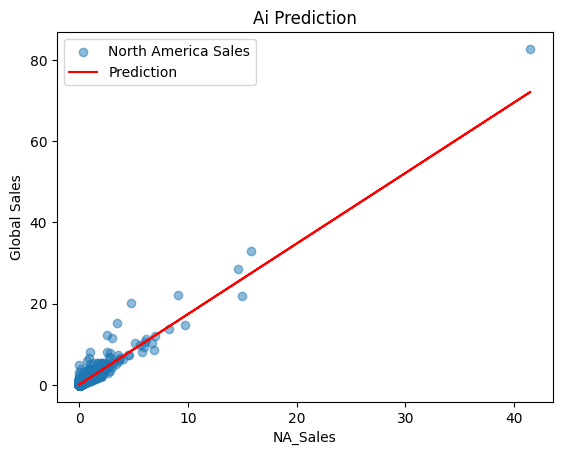

In [8]:
plt.scatter(x_test['NA_Sales'].values, y_test, label="North America Sales", alpha=0.5)
plt.plot(x_test['NA_Sales'].values, prediction, label="Prediction", color='red')

plt.legend()

plt.title("Ai Prediction")
plt.xlabel("NA_Sales")
plt.ylabel("Global Sales")

plt.show()

In [9]:
na_sales = float(input("enter the your game's Sales in South America: "))

dt = pd.DataFrame(
    {
        "NA_Sales": np.array([na_sales])
    }
)
pred = model.predict(dt).round(2)

print(f"Ai Predicted the global sales to be {pred[0]} million")

Ai Predicted the global sales to be 39.32 million
